In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

df = pd.read_csv('marketing_campaign_cleaned.csv')

# Replace the implausible $666,666 income outlier with the average income
# computed excluding that record, then treat the result as the working dataset.
# Method 1: Convert the entire Income column to float first
df['Income'] = df['Income'].astype(float)

avg_income_excl_outlier = df.loc[df['Income'] != 666666, 'Income'].mean()
df.loc[df['Income'] == 666666, 'Income'] = avg_income_excl_outlier
print(f"Replaced Income=666666 with average income: {avg_income_excl_outlier:.2f}")

Replaced Income=666666 with average income: 51972.83


## General Data Overvie

In [38]:
print("First 5 rows:")
print(df.head())

print("\nData types:")
print(df.dtypes)

print("\nMissing values per column:")
print(df.isnull().sum())


First 5 rows:
     ID  Year_Birth   Education Marital_Status   Income  Kidhome  Teenhome  \
0  5524        1957  Graduation         Single  58138.0        0         0   
1  2174        1954  Graduation         Single  46344.0        1         1   
2  4141        1965  Graduation       Together  71613.0        0         0   
3  6182        1984  Graduation       Together  26646.0        1         0   
4  5324        1981         PhD        Married  58293.0        1         0   

  Dt_Customer  Recency  MntWines  MntFruits  MntMeatProducts  MntFishProducts  \
0      9/4/12       58       635         88              546              172   
1      3/8/14       38        11          1                6                2   
2     8/21/13       26       426         49              127              111   
3     2/10/14       26        11          4               20               10   
4     1/19/14       94       173         43              118               46   

   MntSweetProducts  MntGoldPr

## Descriptive Statistics


Summary statistics for numerical columns:
                             mean   median     min       max           std
ID                    5592.159821   5458.5     0.0   11191.0   3246.662198
Year_Birth            1968.805804   1970.0  1893.0    1996.0     11.984069
Income               51972.832068  51741.5  1730.0  162397.0  21405.823560
Kidhome                  0.444196      0.0     0.0       2.0      0.538398
Teenhome                 0.506250      0.0     0.0       2.0      0.544538
Recency                 49.109375     49.0     0.0      99.0     28.962453
MntWines               303.935714    173.5     0.0    1493.0    336.597393
MntFruits               26.302232      8.0     0.0     199.0     39.773434
MntMeatProducts        166.950000     67.0     0.0    1725.0    225.715373
MntFishProducts         37.525446     12.0     0.0     259.0     54.628979
MntSweetProducts        27.062946      8.0     0.0     263.0     41.280498
MntGoldProds            44.021875     24.0     0.0     36

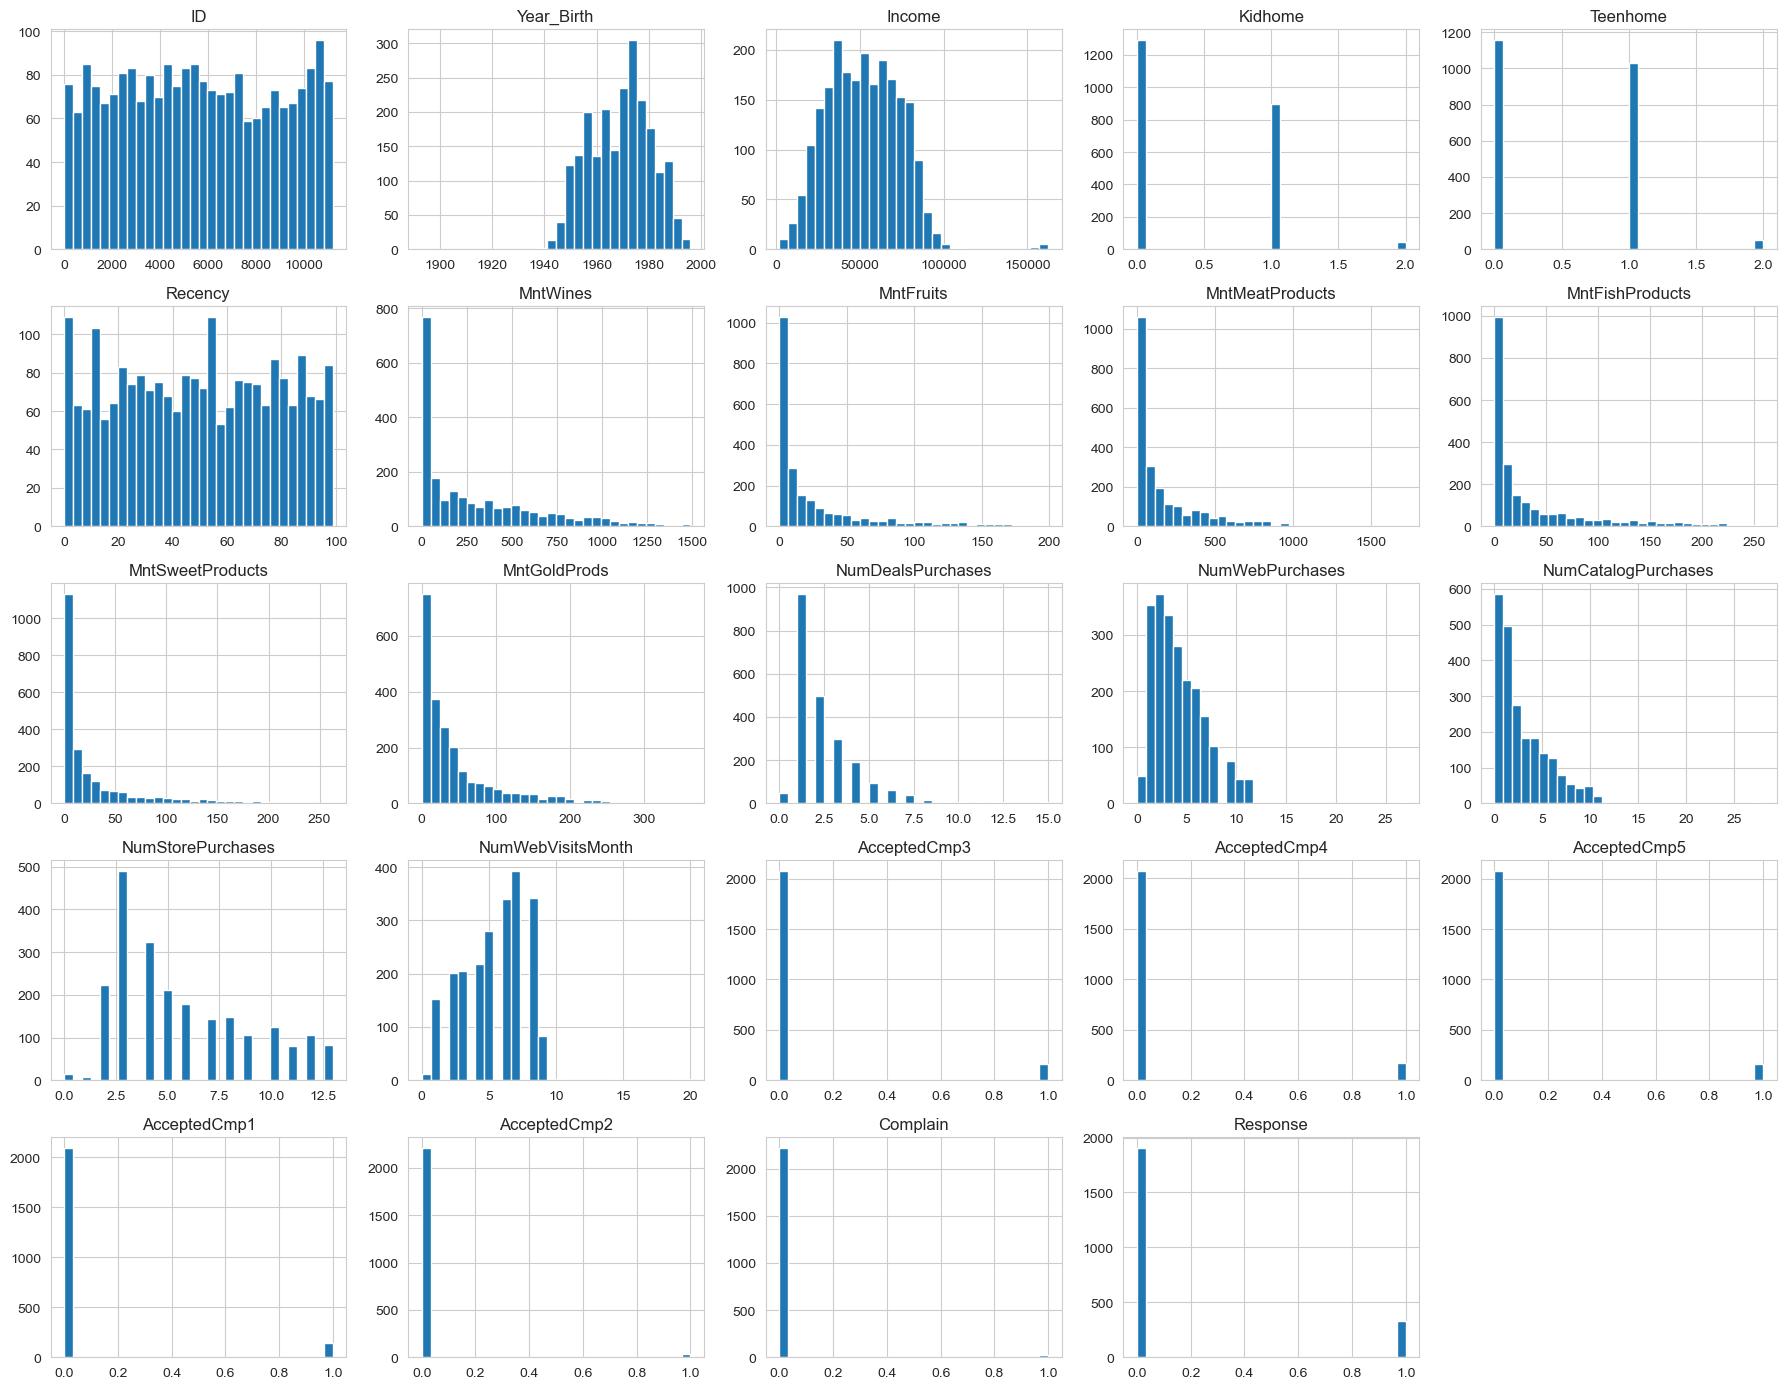

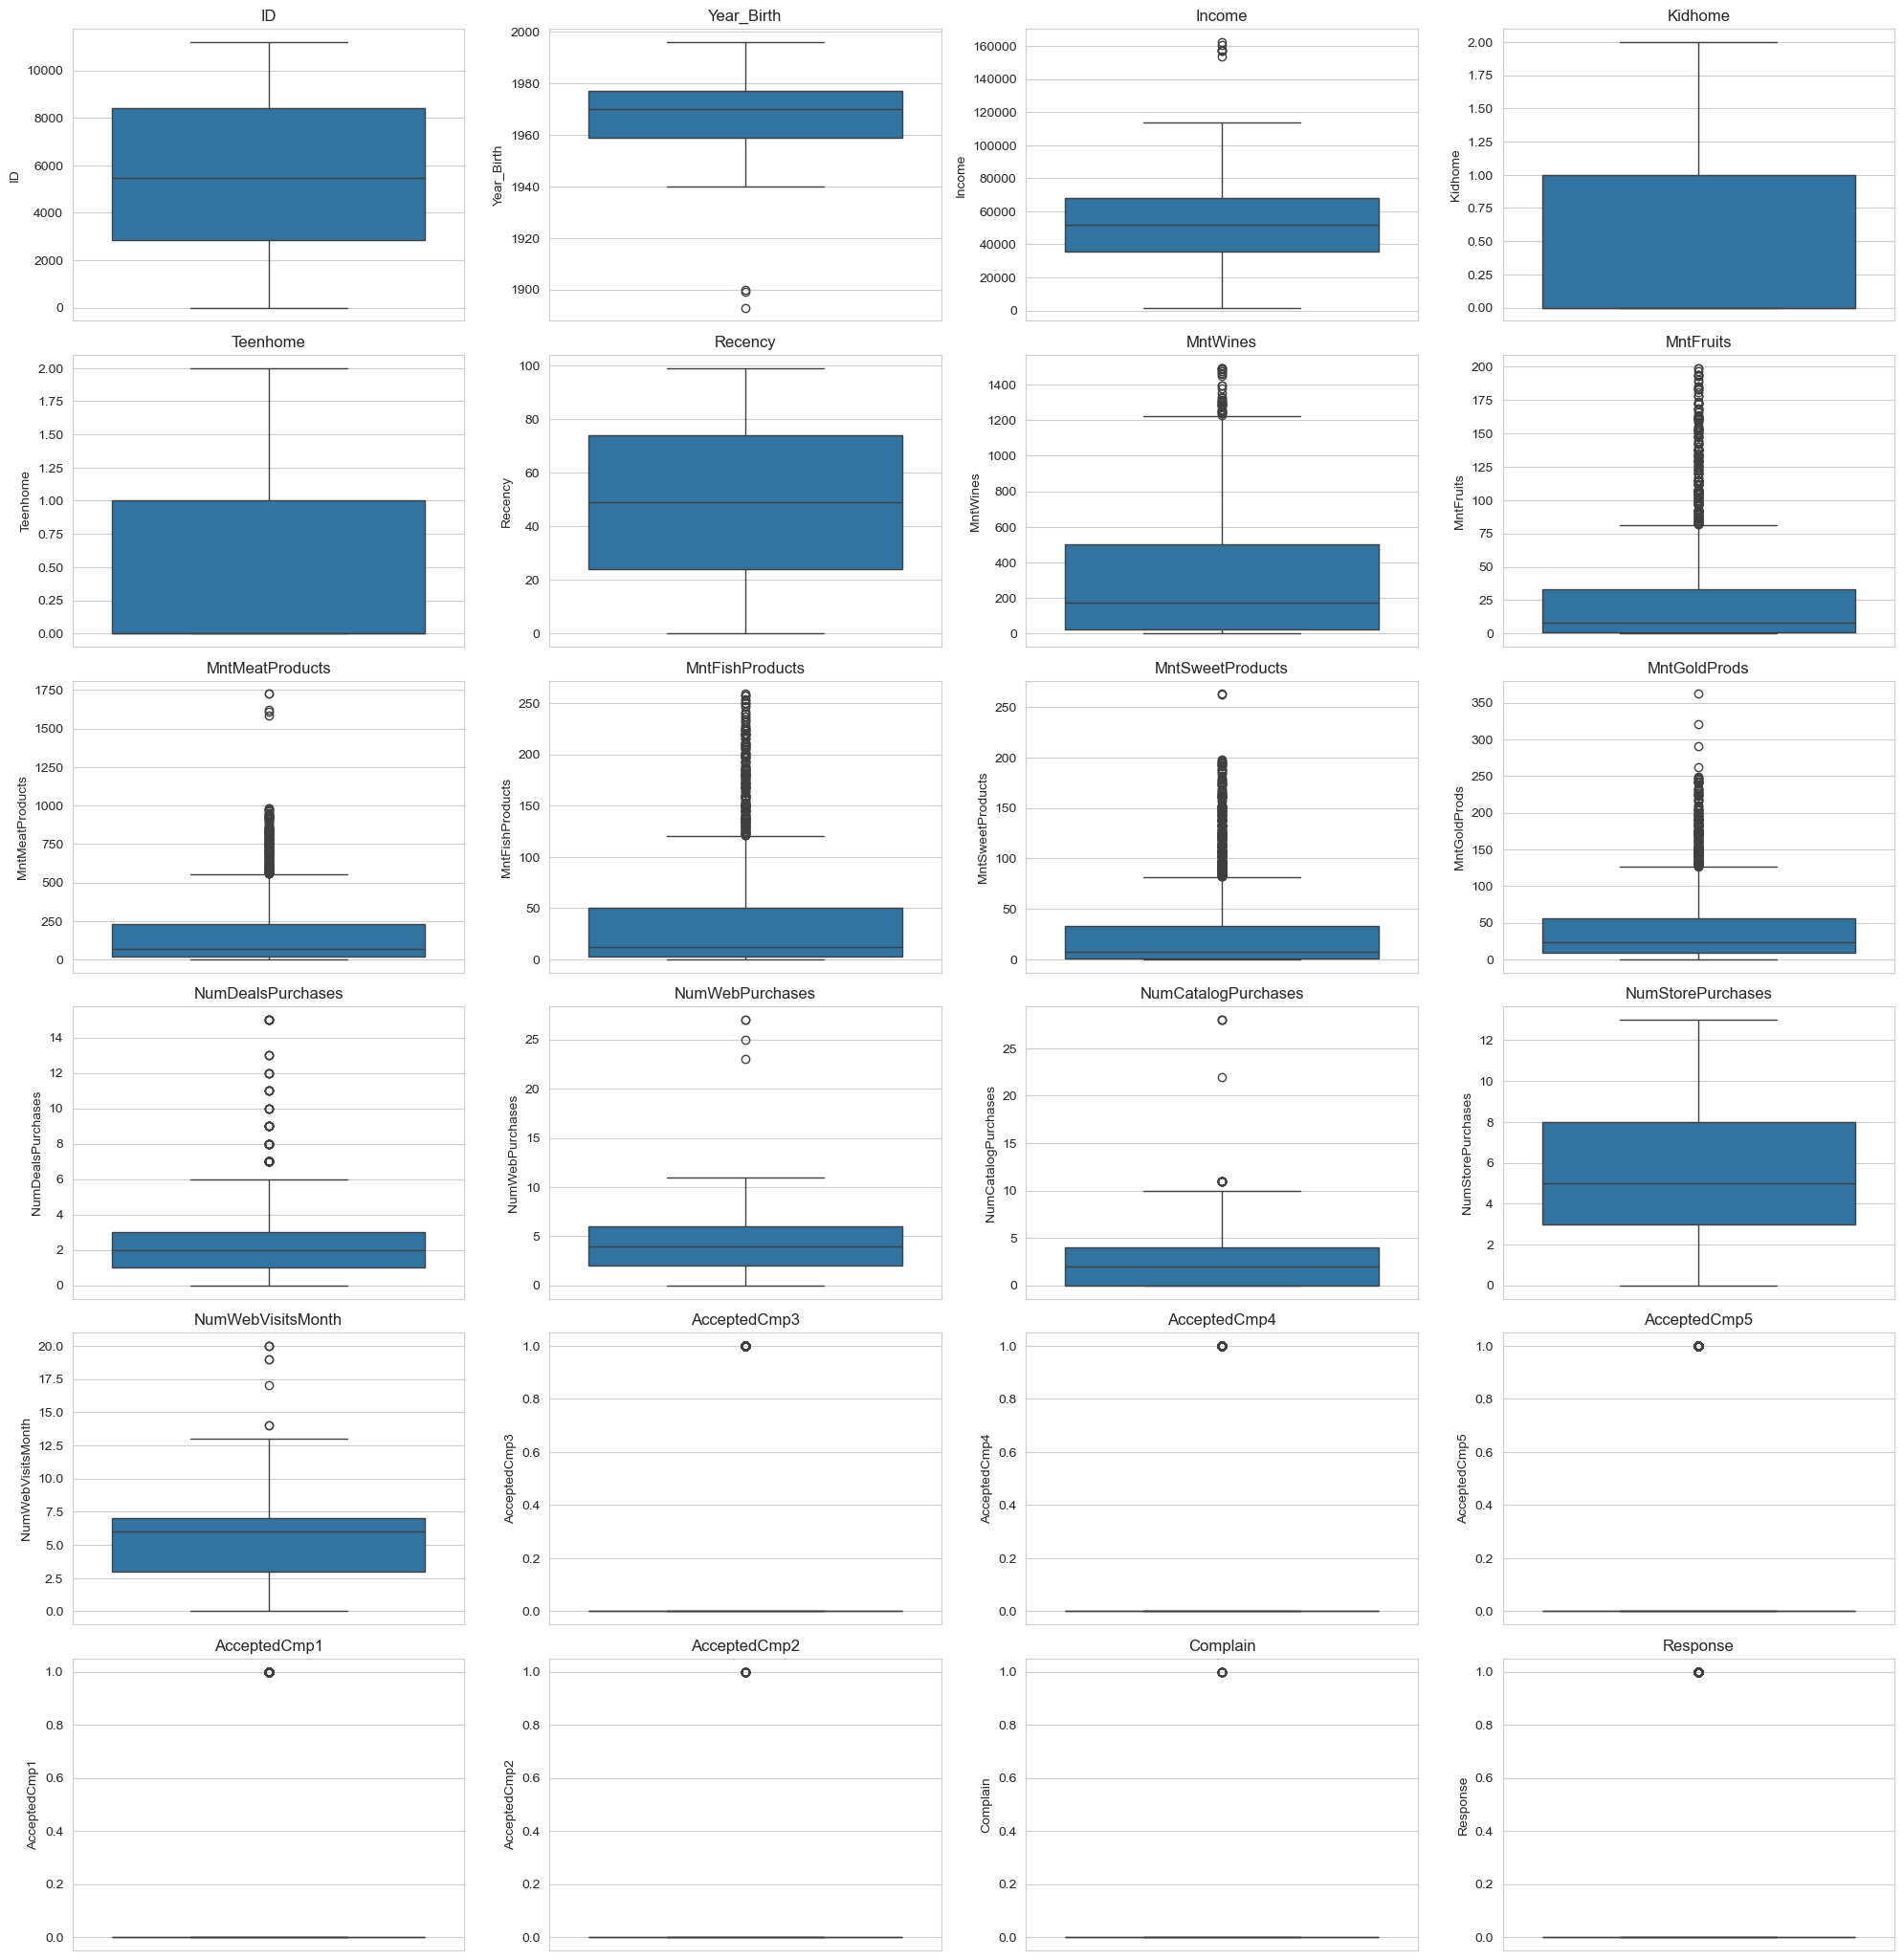

In [39]:
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

print("\nSummary statistics for numerical columns:")
summary_stats = df[numerical_cols].agg(['mean', 'median', 'min', 'max', 'std']).T
print(summary_stats)

# Histograms for all numerical variables
df[numerical_cols].hist(figsize=(18, 14), bins=30)
plt.tight_layout()
plt.show()

# Box plots for all numerical variables
fig, axes = plt.subplots(nrows=(len(numerical_cols) // 4) + 1, ncols=4, figsize=(20, 24))
axes = axes.flatten()
for i, col in enumerate(numerical_cols):
    sns.boxplot(y=df[col], ax=axes[i])
    axes[i].set_title(col)
for j in range(len(numerical_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

## Univariate Analysis

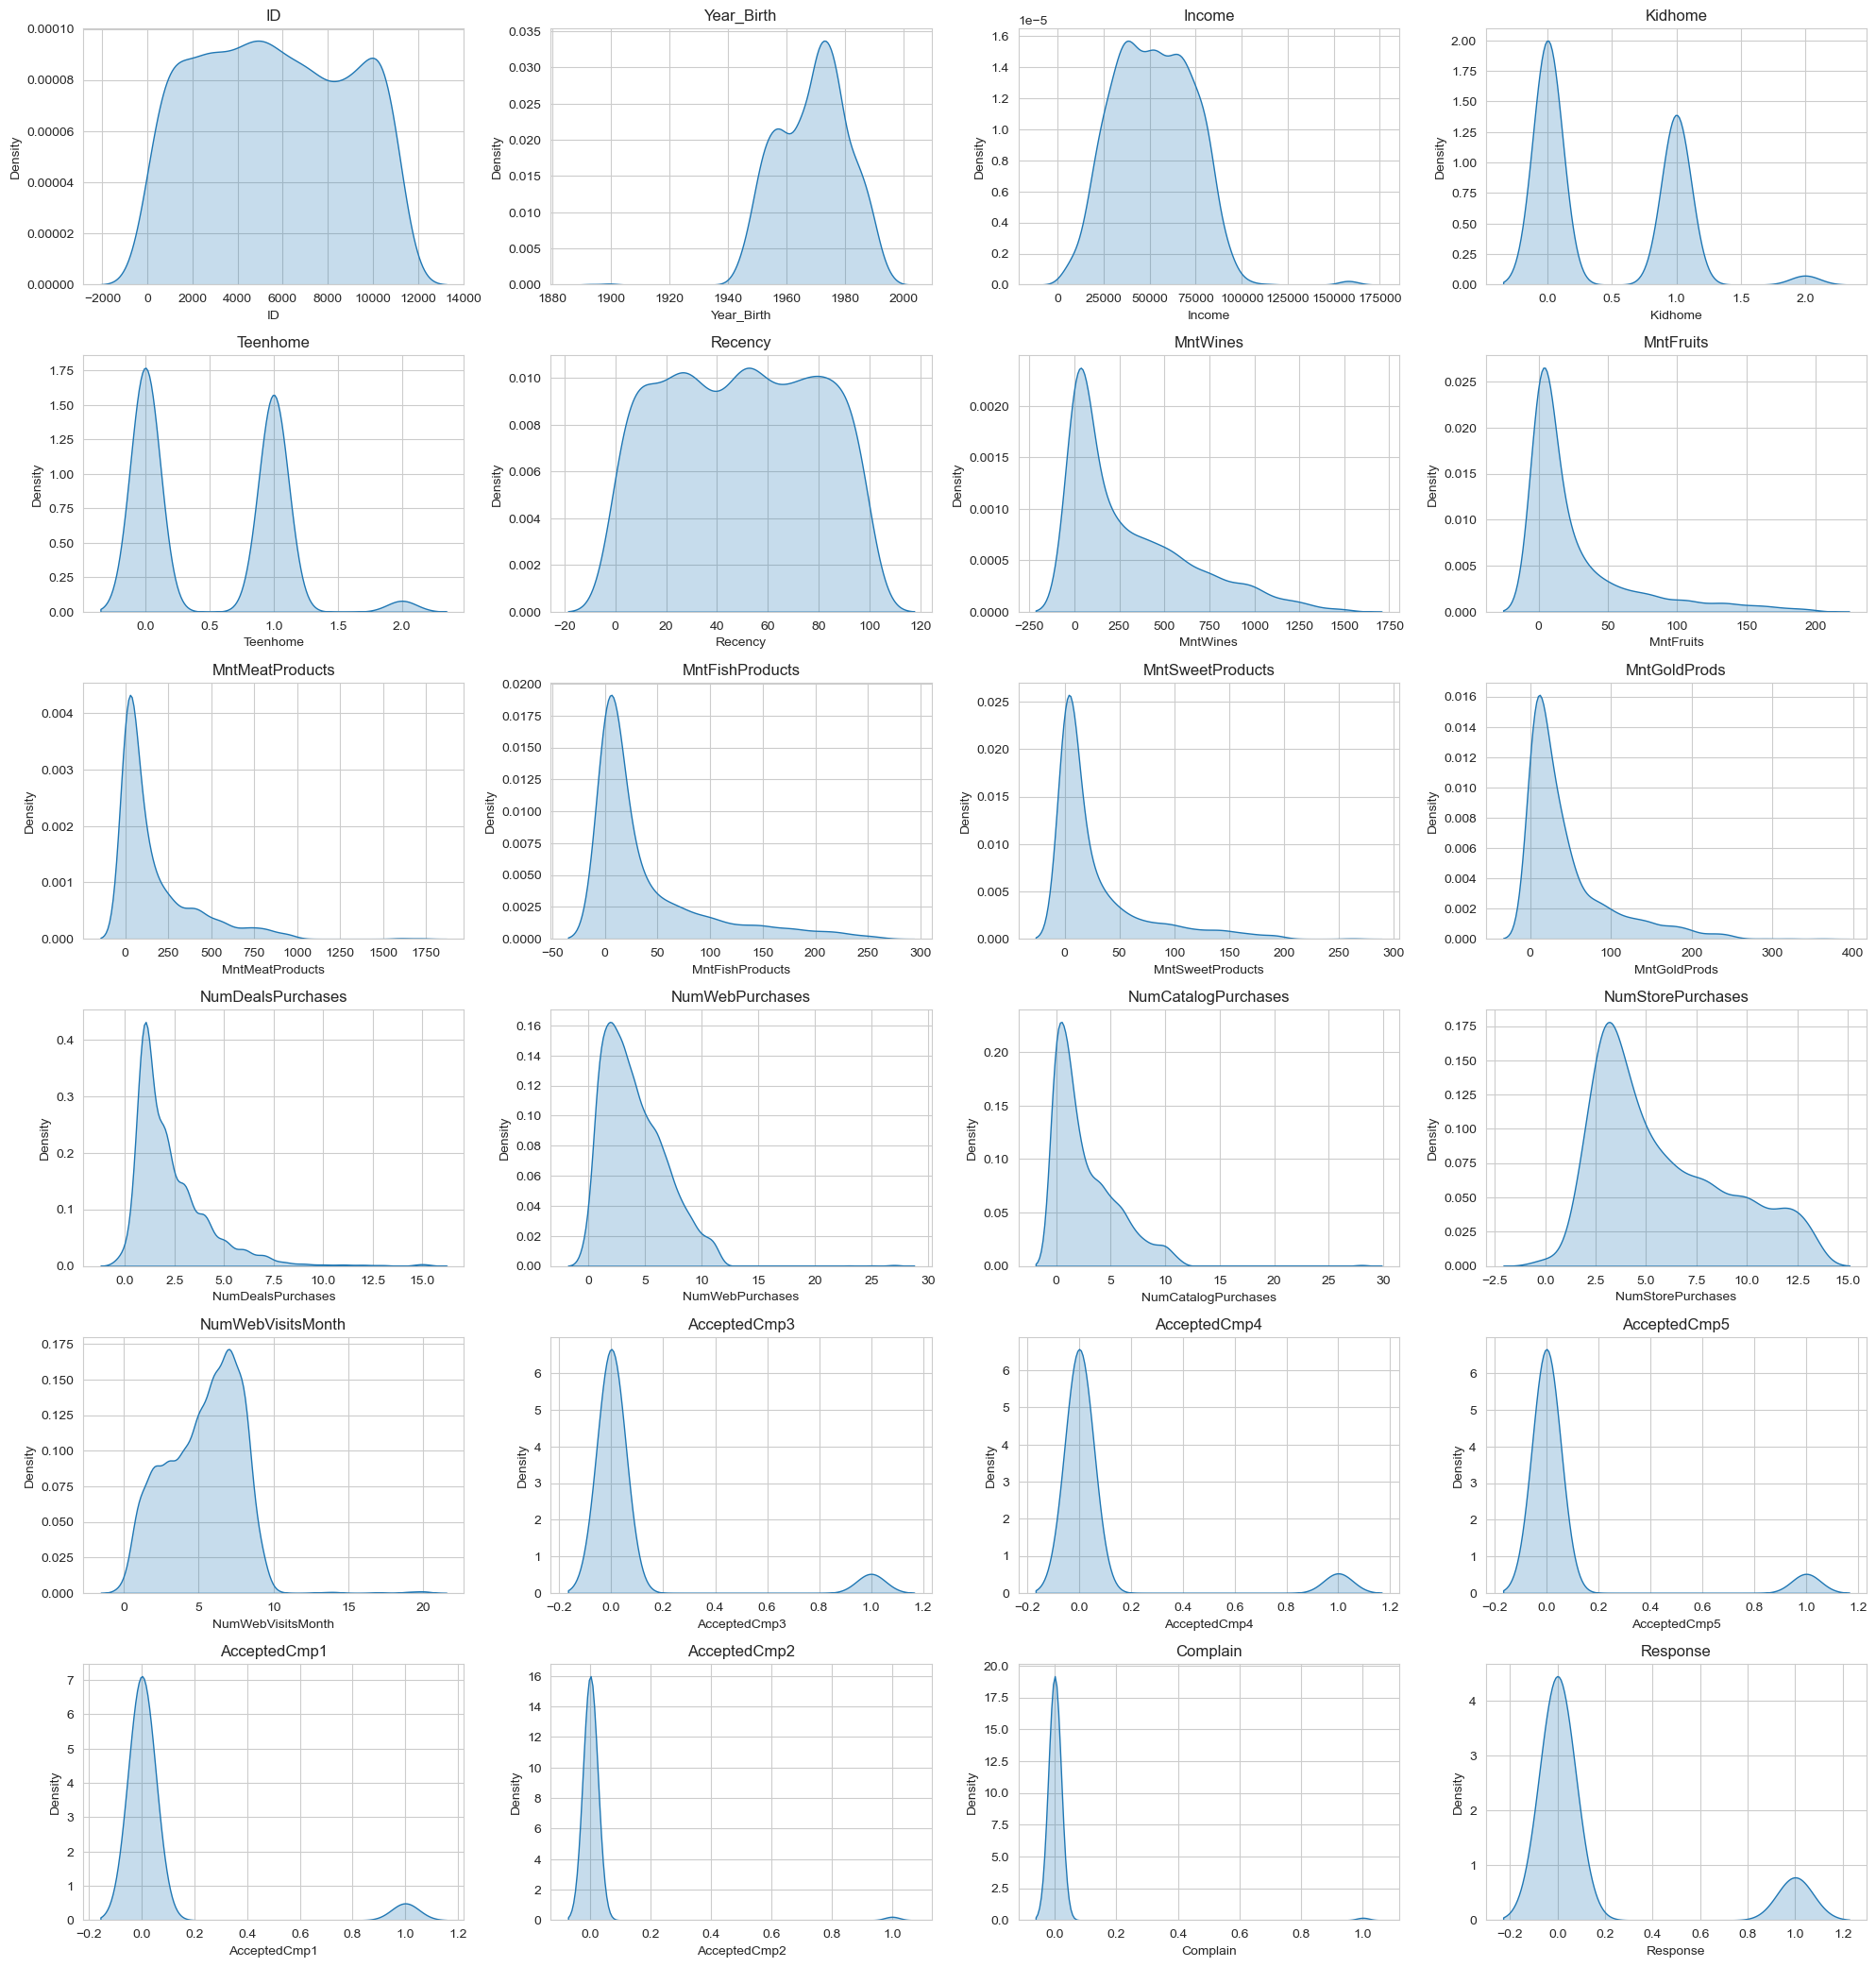

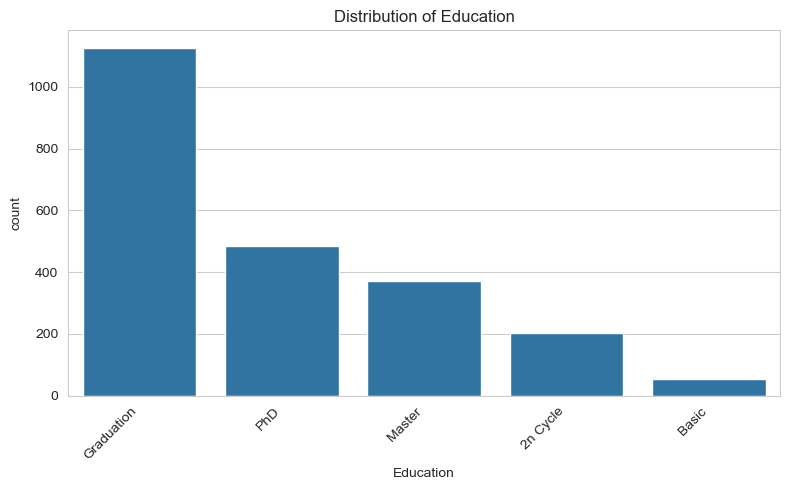

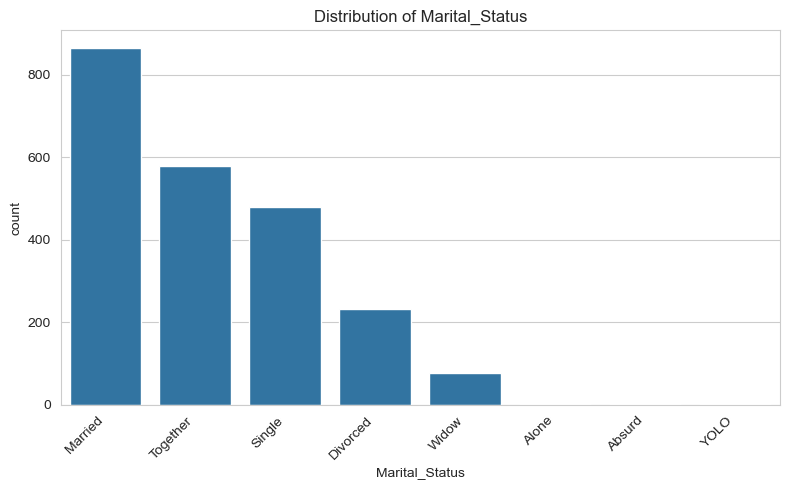

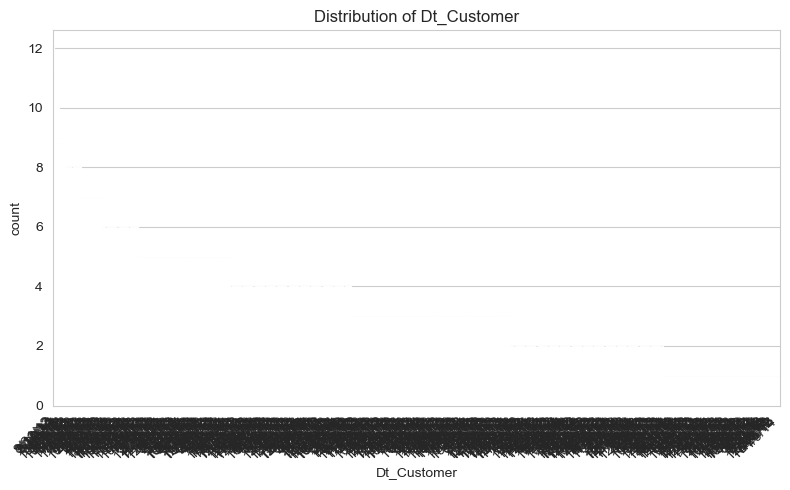

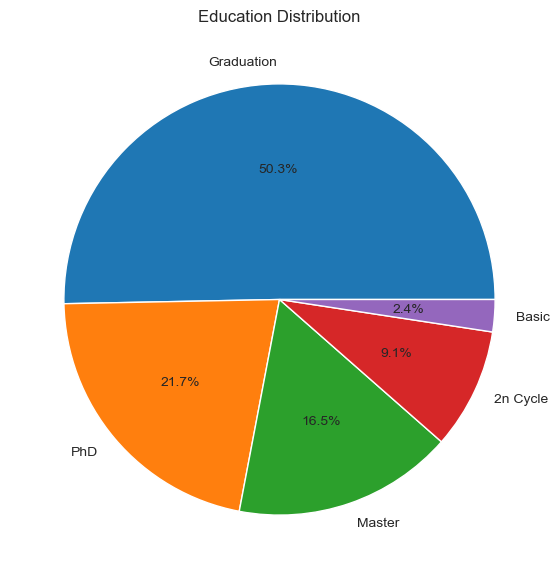


Outlier counts (IQR method) per numerical column:
ID: 0 outliers
Year_Birth: 3 outliers
Income: 7 outliers
Kidhome: 0 outliers
Teenhome: 0 outliers
Recency: 0 outliers
MntWines: 35 outliers
MntFruits: 227 outliers
MntMeatProducts: 175 outliers
MntFishProducts: 223 outliers
MntSweetProducts: 248 outliers
MntGoldProds: 207 outliers
NumDealsPurchases: 86 outliers
NumWebPurchases: 4 outliers
NumCatalogPurchases: 23 outliers
NumStorePurchases: 0 outliers
NumWebVisitsMonth: 8 outliers
AcceptedCmp3: 163 outliers
AcceptedCmp4: 167 outliers
AcceptedCmp5: 163 outliers
AcceptedCmp1: 144 outliers
AcceptedCmp2: 30 outliers
Complain: 21 outliers
Response: 334 outliers


In [40]:
# KDE plots for numerical variables
fig, axes = plt.subplots(nrows=(len(numerical_cols) // 4) + 1, ncols=4, figsize=(20, 24))
axes = axes.flatten()
for i, col in enumerate(numerical_cols):
    sns.kdeplot(df[col].dropna(), ax=axes[i], fill=True)
    axes[i].set_title(col)
for j in range(len(numerical_cols), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

# Bar plots for categorical variables
for col in categorical_cols:
    plt.figure(figsize=(8, 5))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# Pie chart example for Education
plt.figure(figsize=(7, 7))
df['Education'].value_counts().plot.pie(autopct='%1.1f%%')
plt.title('Education Distribution')
plt.ylabel('')
plt.show()

# Outlier detection via box plots (already generated above); IQR-based outlier count
print("\nOutlier counts (IQR method) per numerical column:")
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outliers")

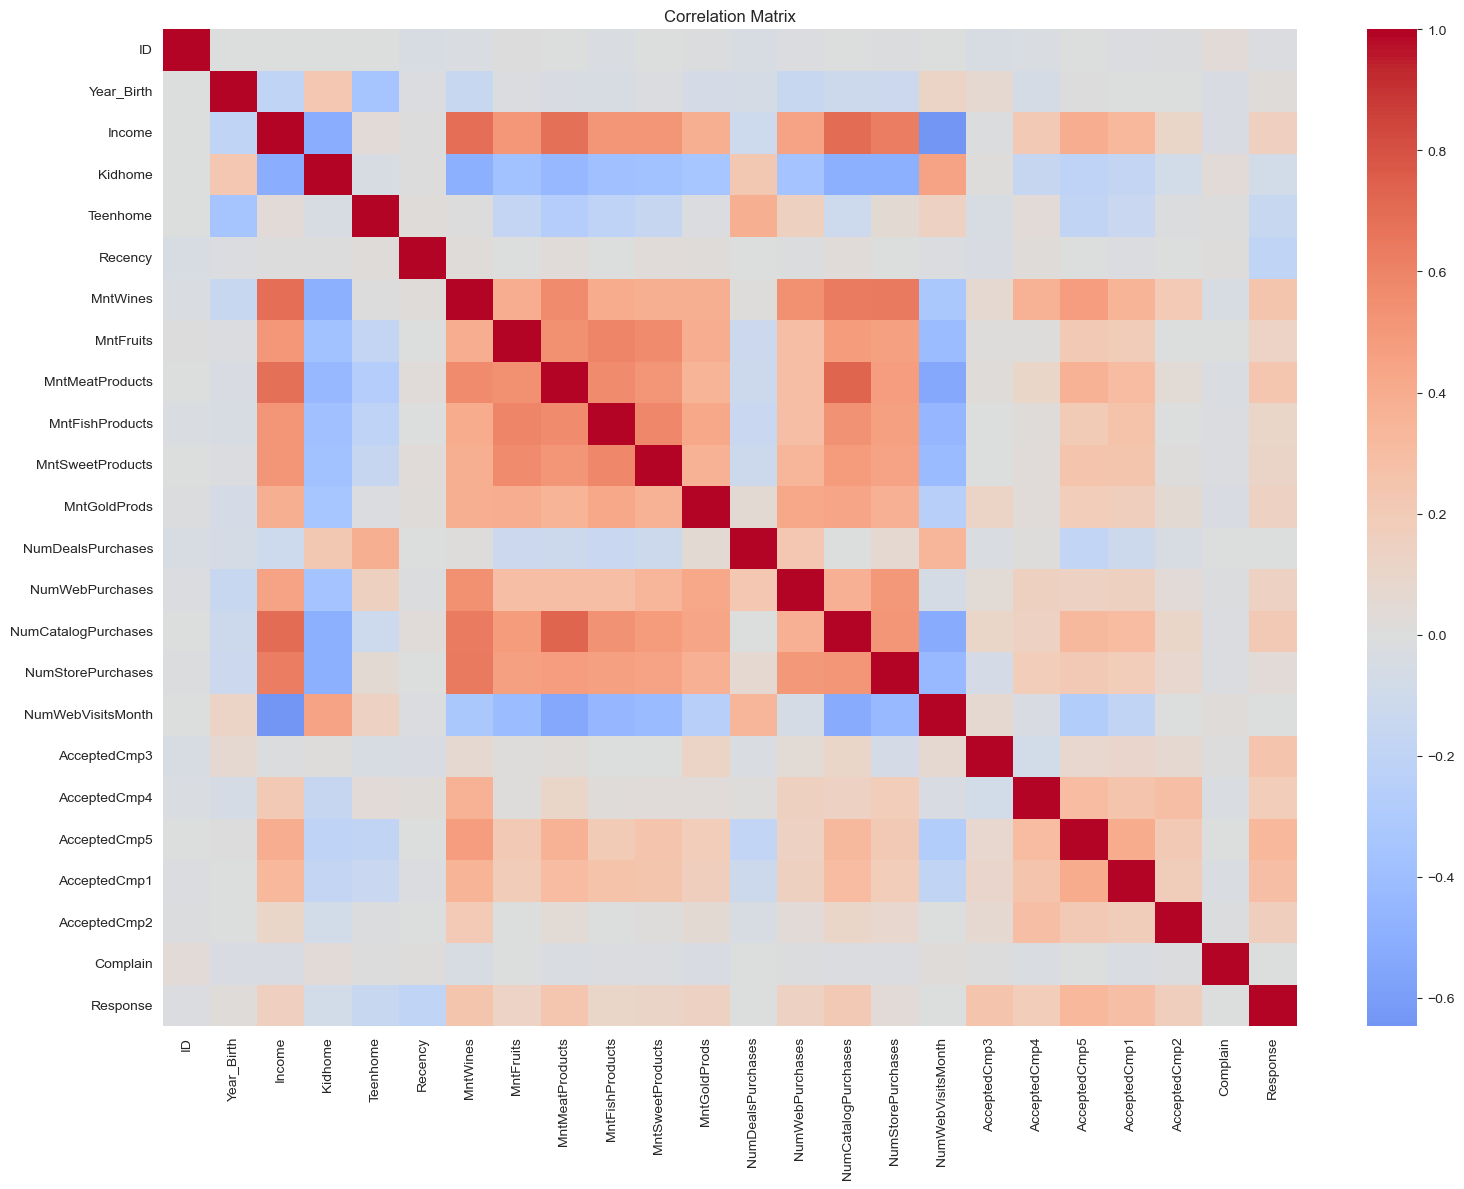


Correlation of numerical variables with Response:
Response               1.000000
AcceptedCmp5           0.326634
AcceptedCmp1           0.293982
AcceptedCmp3           0.254258
MntWines               0.247254
MntMeatProducts        0.236335
NumCatalogPurchases    0.220810
AcceptedCmp4           0.177019
AcceptedCmp2           0.169293
Income                 0.160649
NumWebPurchases        0.148730
MntGoldProds           0.139850
MntFruits              0.125289
MntSweetProducts       0.117372
MntFishProducts        0.111331
NumStorePurchases      0.039363
Year_Birth             0.021325
NumDealsPurchases      0.002238
Complain              -0.001707
NumWebVisitsMonth     -0.003987
ID                    -0.021968
Kidhome               -0.080008
Teenhome              -0.154446
Recency               -0.198437
Name: Response, dtype: float64


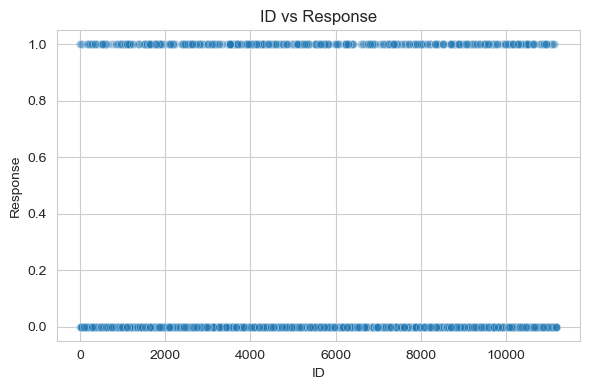

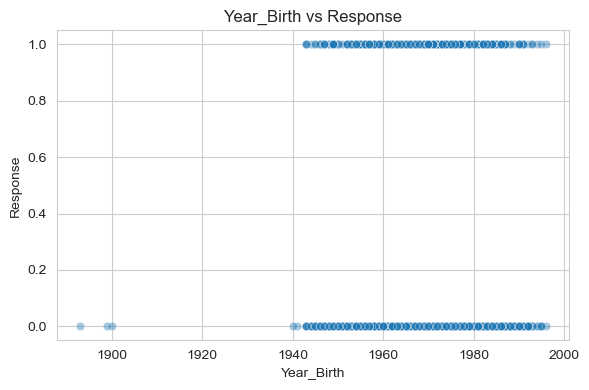

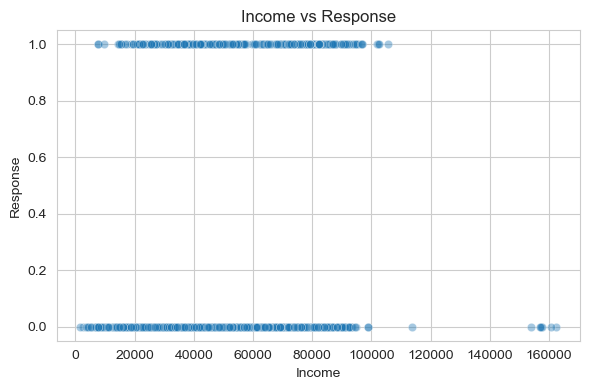

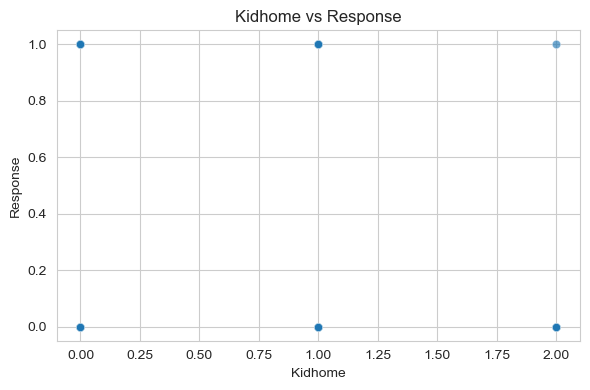

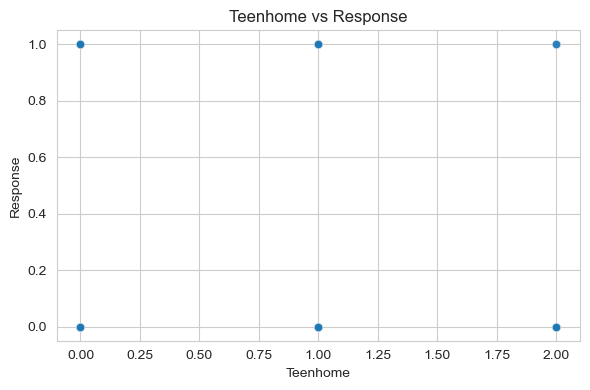

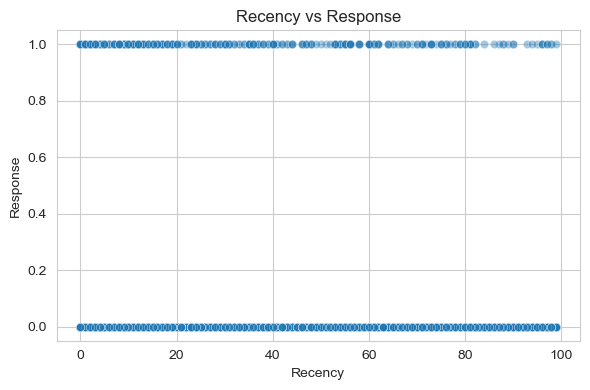

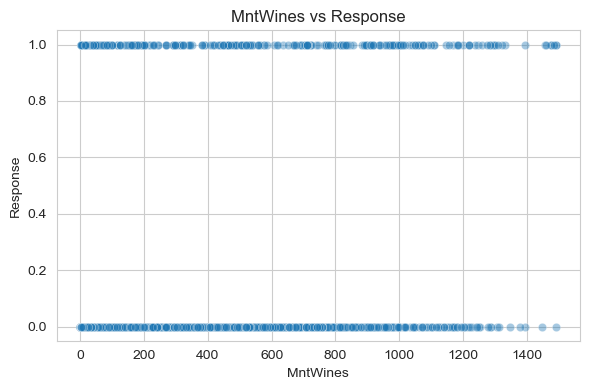

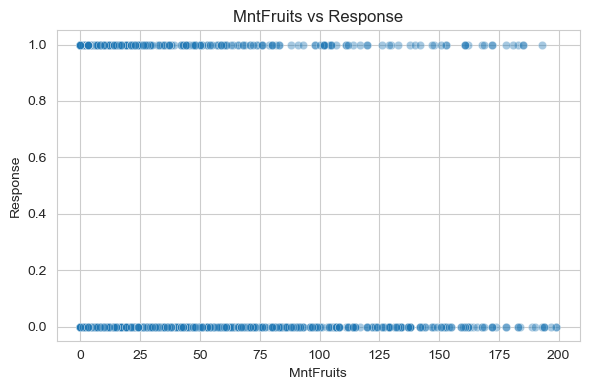

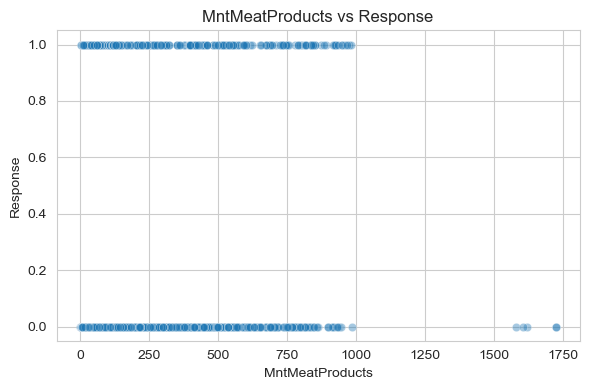

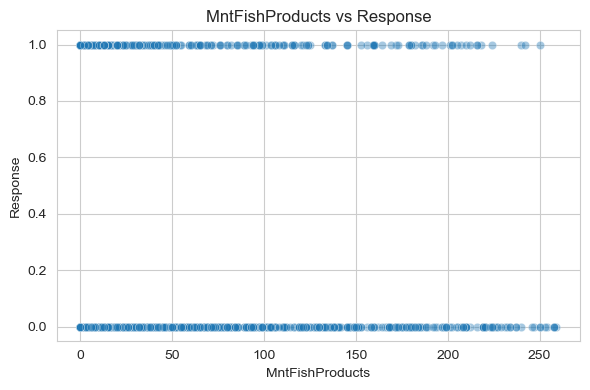

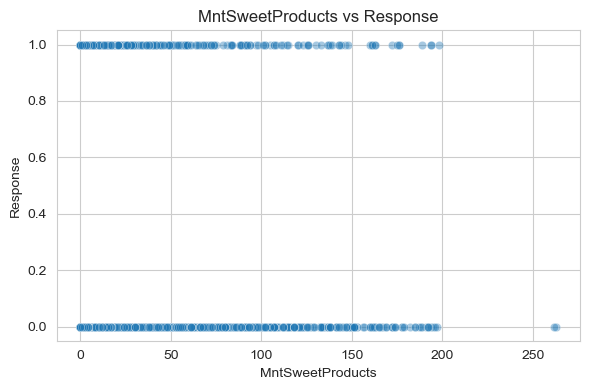

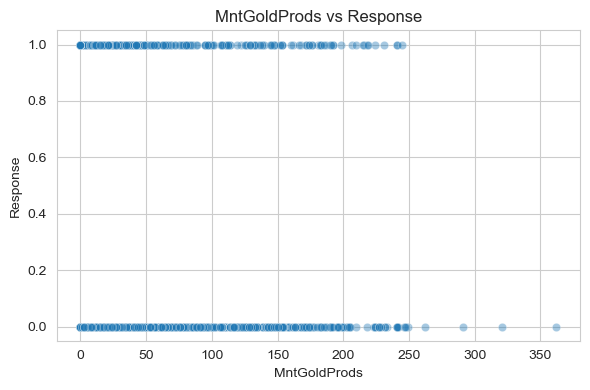

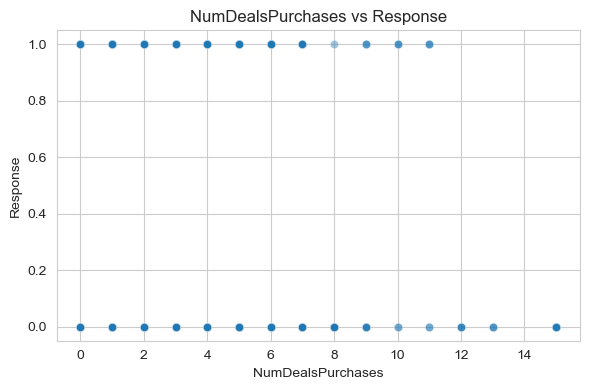

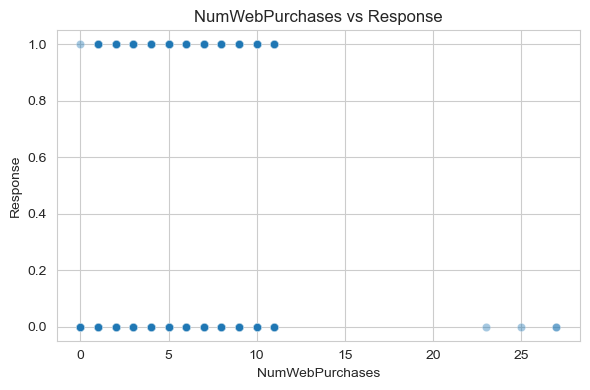

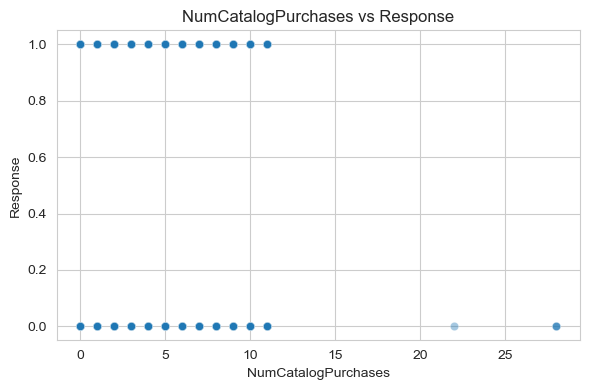

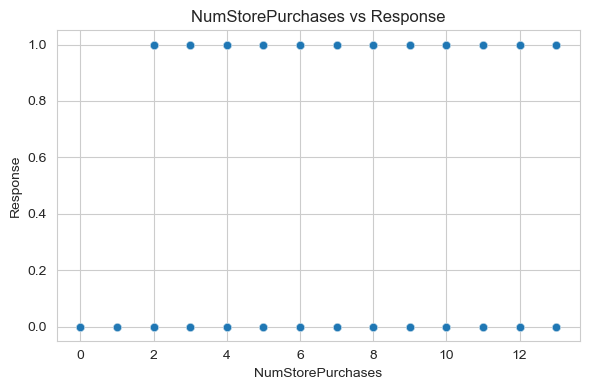

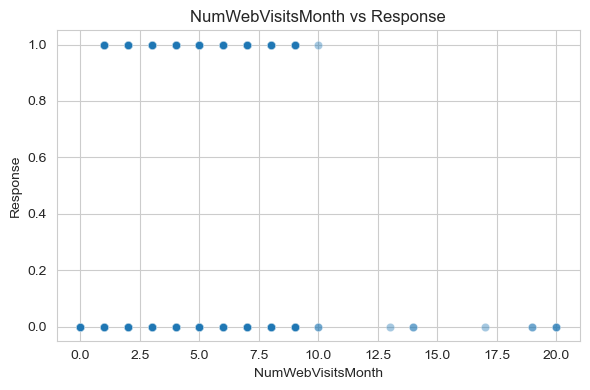

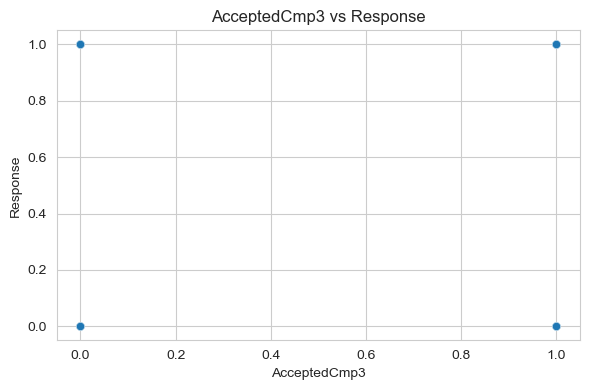

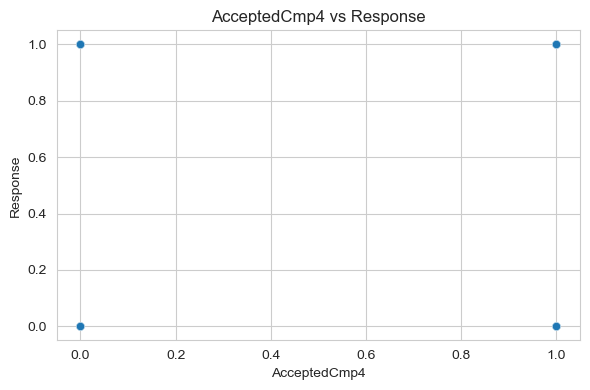

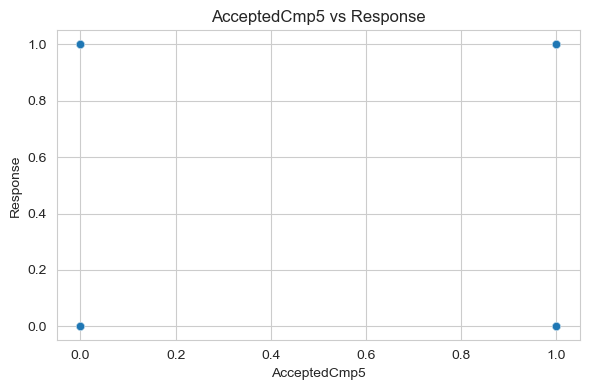

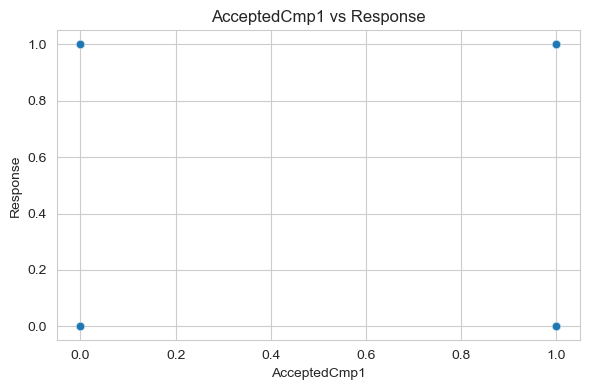

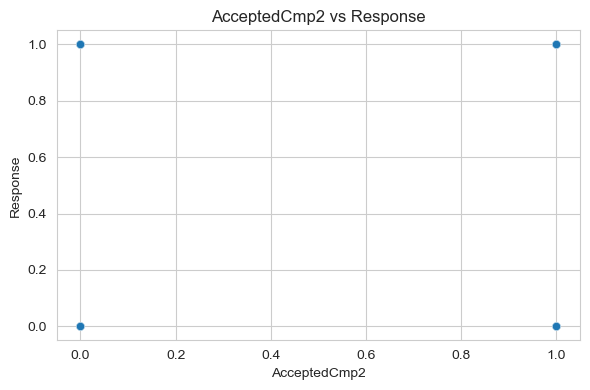

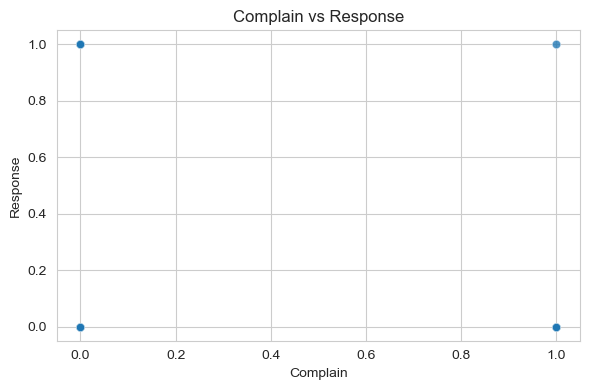


Chi-square tests: categorical variables vs Response
Education: chi2=23.076, p-value=0.00012


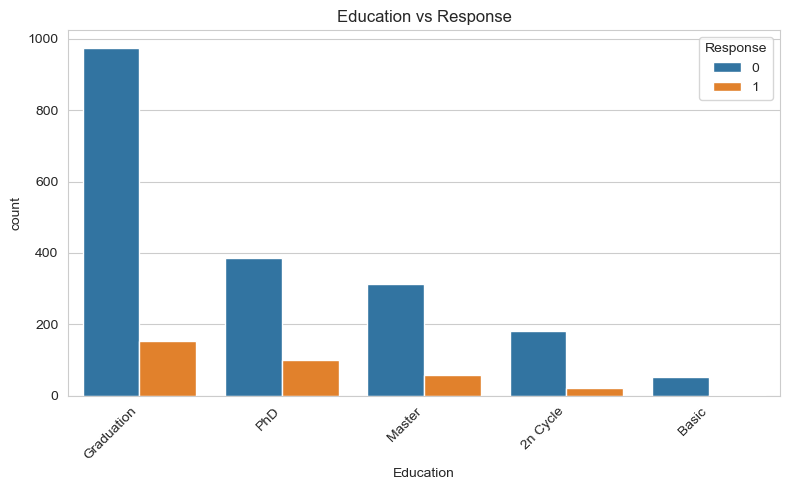

Marital_Status: chi2=54.242, p-value=0.00000


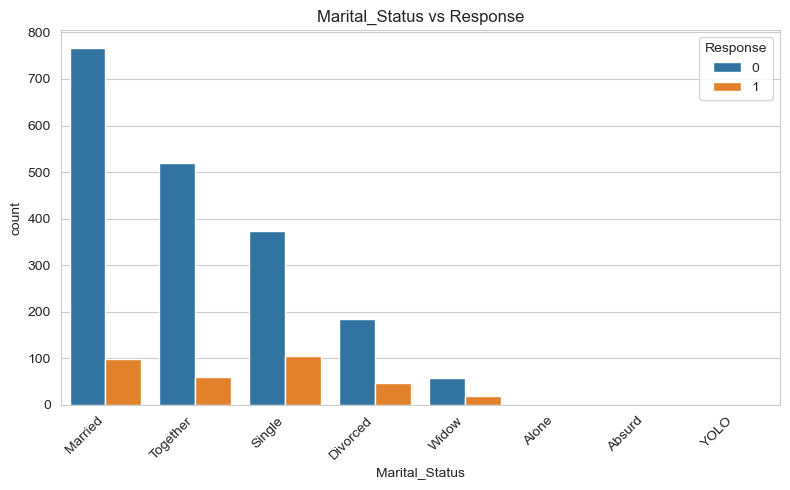

Dt_Customer: chi2=775.266, p-value=0.00149


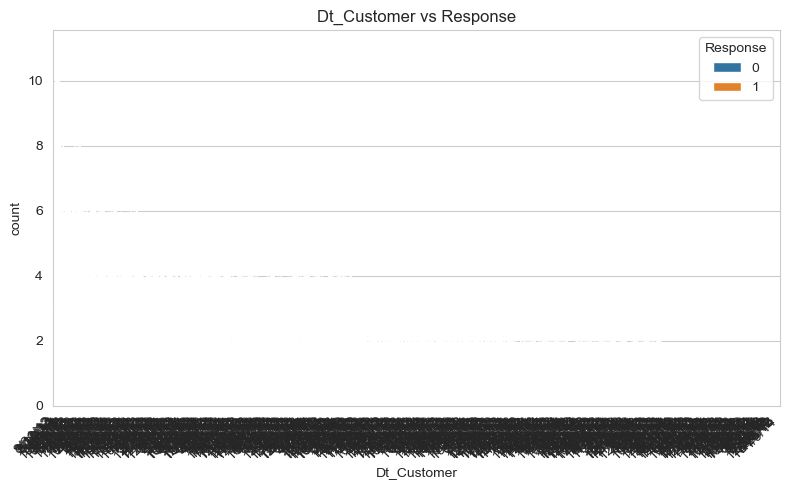

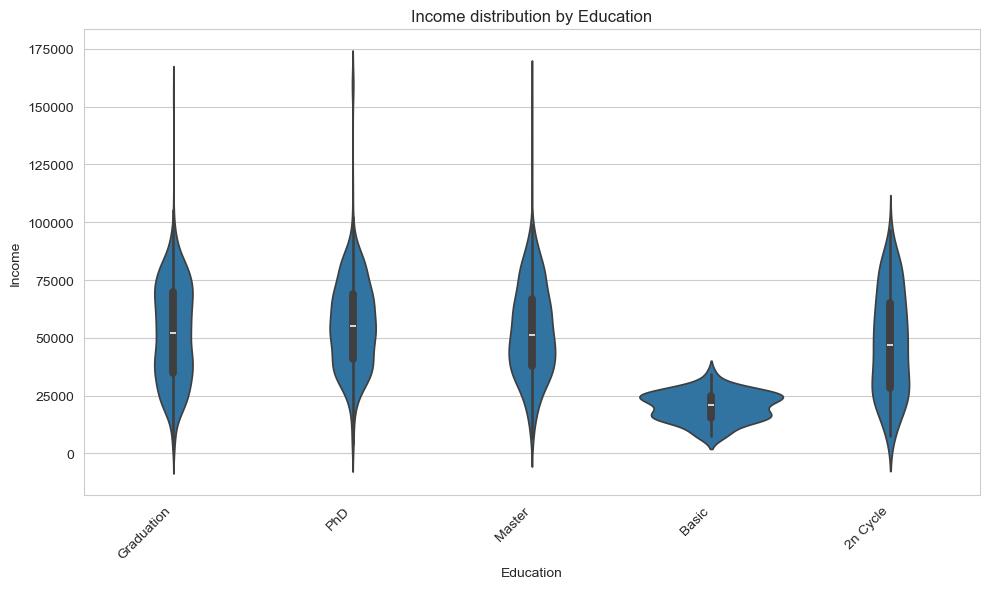

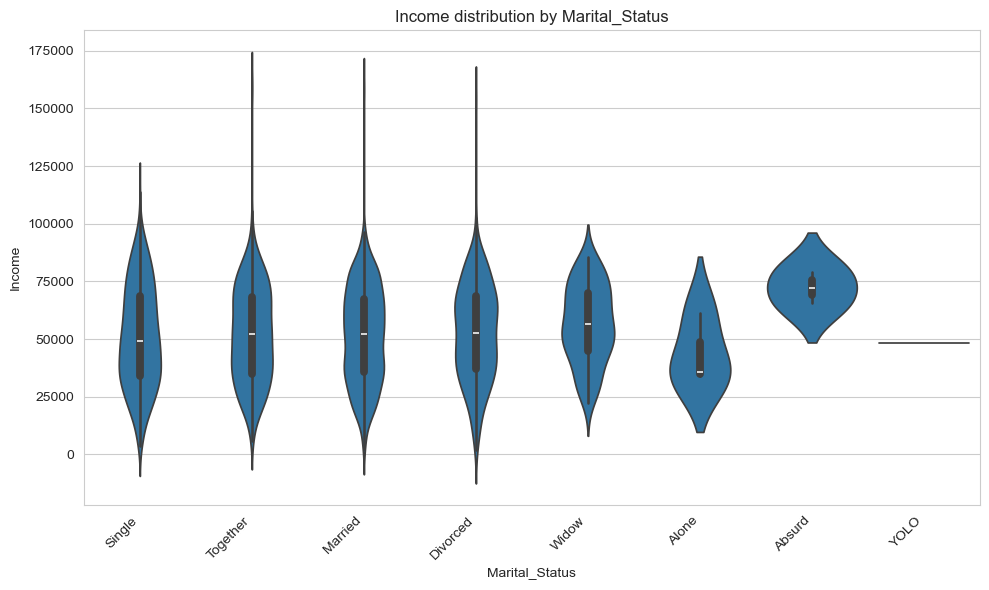

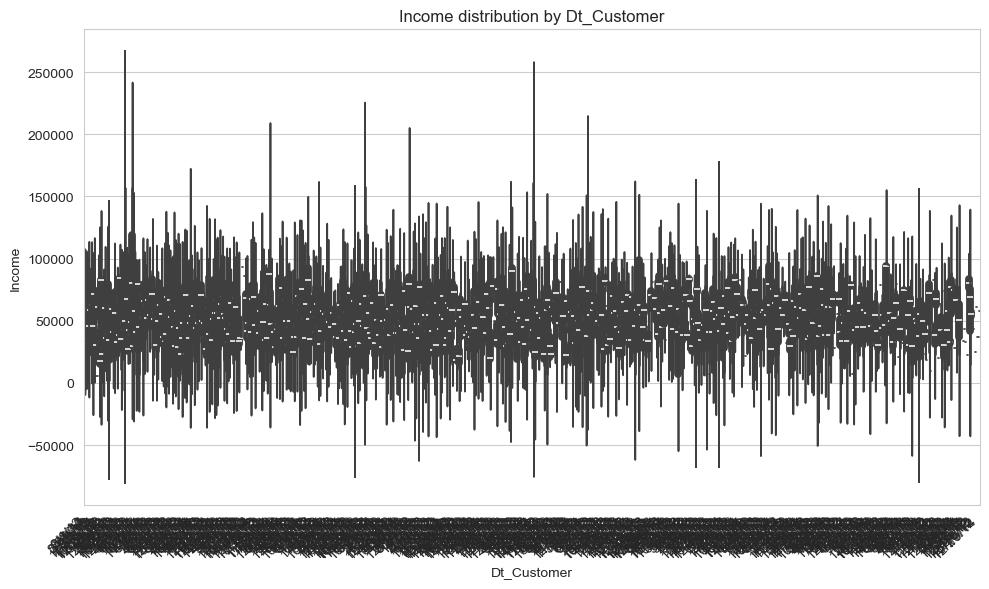

In [41]:
# Correlation matrix including Response
corr_matrix = df[numerical_cols].corr()
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

print("\nCorrelation of numerical variables with Response:")
print(corr_matrix['Response'].sort_values(ascending=False))

# Scatter plots: numerical variables vs Response
for col in [c for c in numerical_cols if c != 'Response']:
    plt.figure(figsize=(6, 4))
    sns.scatterplot(data=df, x=col, y='Response', alpha=0.4)
    plt.title(f'{col} vs Response')
    plt.tight_layout()
    plt.show()

# Categorical variables vs Response: bar plots + chi-square tests
print("\nChi-square tests: categorical variables vs Response")
for col in categorical_cols:
    contingency = pd.crosstab(df[col], df['Response'])
    chi2, p, dof, expected = chi2_contingency(contingency)
    print(f"{col}: chi2={chi2:.3f}, p-value={p:.5f}")

    plt.figure(figsize=(8, 5))
    sns.countplot(data=df, x=col, hue='Response', order=df[col].value_counts().index)
    plt.title(f'{col} vs Response')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# Numerical vs categorical: box/violin plots (e.g., Income by Education, Income by Marital_Status)
for cat_col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.violinplot(data=df, x=cat_col, y='Income')
    plt.title(f'Income distribution by {cat_col}')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

1. **Data structure/quality** — no missing values, but two integrity issues found: the corrected $666,666 income outlier (now $51,972.83) and an uncorrected implausible `Year_Birth` (1893).
2. **Descriptive stats** — right-skewed spending columns, imbalanced target (`Response` mean 0.149).
3. **Univariate findings** — skew confirmed across spend columns; binary-column "outliers" flagged as an artifact of using IQR on 0/1 fields, not real anomalies.
4. **Bivariate findings** — campaign history and spend behavior are the strongest predictors of `Response` (much stronger than demographics); both chi-square tests (Education, Marital_Status) are significant.
5. **Fraud-detection implications** — five concrete takeaways: prioritize behavioral over demographic features, handle class imbalance explicitly, validate data before modeling, match outlier technique to variable type, and treat recency as a high-value feature (consistent with fraud velocity heuristics).